In [ ]:
#from ipysigma import Sigma
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import time
import random
import IPython
from scipy.integrate import solve_ivp
import networkx as nx
from  networkx.algorithms.approximation import min_weighted_dominating_set as dominating_set
import seaborn as sns


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set random seeds for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"Random seeds set to {RANDOM_SEED}")

Random seeds set to 42


In [ ]:
def generate_test_network(model_type="BA", n=1000):
    if model_type == "BA":
        # Scale-free: 2 edges per new node
        return nx.barabasi_albert_graph(n, 2)
    elif model_type == "WS":
        # Small-world: k=6, rewiring p=0.1
        return nx.watts_strogatz_graph(n, 6, 0.1)
    elif model_type == "SBM":
        # Community structure: 2 communities of 500
        sizes = [500, 500]
        probs = [[0.1, 0.01], [0.01, 0.1]]
        return nx.stochastic_block_model(sizes, probs)
    else:
        raise ValueError("Unknown model")

def degree_preserving_edge_swapping(G, num_swaps=1000):
    """
    Performs degree-preserving edge swapping on a graph.

    Args:
        G (nx.Graph): The input graph.
        num_swaps (int): The number of edge swap attempts to perform.

    Returns:
        nx.Graph: A new graph with randomized topology but preserved degree sequence.
    """
    G_copy = G.copy() # Work on a copy to preserve the original graph
    edges = list(G_copy.edges())
    n_edges = len(edges)

    if n_edges < 2:
        return G_copy # Not enough edges to swap

    for _ in range(num_swaps):
        # Randomly select two distinct edges
        e1_idx, e2_idx = random.sample(range(n_edges), 2)
        u, v = edges[e1_idx]
        x, y = edges[e2_idx]

        # Check for valid swap conditions
        # 1. New edges (u, y) and (x, v) must not create self-loops
        # 2. New edges must not already exist (avoid parallel edges in simple graphs)
        if u != y and x != v and \
           not G_copy.has_edge(u, y) and not G_copy.has_edge(x, v) and \
           u != x and u != y and v != x and v != y: # Ensure four distinct nodes or that a swap doesn't just re-create existing edges under different node assignments.
            # Perform the swap
            G_copy.remove_edge(u, v)
            G_copy.remove_edge(x, y)
            G_copy.add_edge(u, y)
            G_copy.add_edge(x, v)

            # Update edges list for subsequent swaps
            edges[e1_idx] = (u, y)
            edges[e2_idx] = (x, v)

    return G_copy

In [ ]:
class EpidemicSimulator:
    def __init__(self, G):
        self.G = G
        self.A = nx.to_numpy_array(G)
        self.n = len(G)

    def _ode_system(self, t, y, gamma_nodes, W_beta, W_epsilon):
        S = y[0 : self.n]
        I = y[self.n : 2 * self.n]
        R = y[2 * self.n : 3 * self.n]

        # Local infection force
        Lambda = I @ W_beta
        Omega = I @ W_epsilon

        dSdt = - S * Lambda
        dIdt = S * Lambda - gamma_nodes * I + R * Omega
        dRdt = -dSdt -dIdt

        return np.concatenate([dSdt, dIdt, dRdt])

    def run_siri_v(self, m, vaccinated, params, initials, mode="SIRI"):
        vac = np.array(vaccinated)

        beta_nodes = np.where(vac, params['b'], params['beta'])
        eps_nodes = np.where(vac, params['e'], params['epsilon'])
        gamma_nodes = np.where(vac, params['g'], params['gamma'])
        h_neighbor = params['h']

        # Effective weight matrices j -> i
        B = np.where(vac[:, None], h_neighbor, beta_nodes[None, :])
        E = np.where(vac[:, None], h_neighbor, eps_nodes[None, :])

        W_beta = self.A * B
        W_epsilon = self.A * E

        if mode == "SI":
            gamma_nodes = np.zeros(self.n)
            W_epsilon = np.zeros((self.n, self.n))

        y0 = np.concatenate([initials['S'], initials['I'], initials['R']])
        t_span = (0, m - 1)
        t_eval = np.arange(m)

        sol = solve_ivp(
            self._ode_system,
            t_span,
            y0,
            t_eval=t_eval,
            args=(gamma_nodes, W_beta, W_epsilon),
            method='RK45'
        )

        S_hist = sol.y[0 : self.n, :]
        I_hist = sol.y[self.n : 2 * self.n, :]
        R_hist = sol.y[2 * self.n : 3 * self.n, :]

        # Returns nodal details necessary for metric evaluation
        return S_hist, I_hist, R_hist, W_epsilon, vac


class EpidemicEvaluator:
    def __init__(self, G):
        self.G = G
        self.n = len(G)

    def compute_metrics(self, S_hist, I_hist, R_hist, W_epsilon, vac, vc, baseline_attack_rate=None):
        metrics = {}

        # Total population by compartment at each time step
        S_total = np.sum(S_hist, axis=0)
        I_total = np.sum(I_hist, axis=0)
        R_total = np.sum(R_hist, axis=0)

        # 1. Temporal Dynamics (Curve Analysis)
        metrics['I_max'] = np.max(I_total)  # Peak prevalence
        metrics['T_peak'] = np.argmax(I_total)  # Time of peak
        metrics['Attack_Rate'] = 1.0 - (S_total[-1] / self.n)  # Final epidemic size

        # 2. Network Connectivity & Robustness
        # Vaccinated nodes are considered "topologically removed" if their immunity is strong
        unvaccinated_nodes = [u for u in self.G.nodes() if not vac[u]]
        if len(unvaccinated_nodes) > 0:
            G_rem = self.G.subgraph(unvaccinated_nodes)
            # Size of the largest remaining connected component
            metrics['Giant_Component'] = max(len(c) for c in nx.connected_components(G_rem))
            # Algebraic connectivity (second smallest eigenvalue of the Laplacian)
            try:
                metrics['Algebraic_Connectivity'] = nx.algebraic_connectivity(G_rem)
            except:
                metrics['Algebraic_Connectivity'] = 0.0
        else:
            metrics['Giant_Component'] = 0
            metrics['Algebraic_Connectivity'] = 0.0

        # Mean effective degree (only links to unvaccinated neighbors are counted)
        eff_degrees = [sum(1 for nbr in self.G.neighbors(node) if not vac[nbr]) for node in self.G.nodes()]
        metrics['Mean_Effective_Degree'] = np.mean(eff_degrees)

        # 3. Strategy Efficiency Metrics
        if baseline_attack_rate is not None and vc > 0:
            metrics['Vaccine_Efficiency'] = (baseline_attack_rate - metrics['Attack_Rate']) / vc
        else:
            metrics['Vaccine_Efficiency'] = 0.0

        # 4. SIRI Specific: Re-infection & Persistence
        # Persistence: does the virus remain endemic at the end of the simulation? (threshold at 0.5% of population)
        metrics['Persistence'] = 1 if (I_total[-1] / self.n) > 0.005 else 0

        # Cumulative reinfection rate: Sum over t of (R_i(t) * Omega_i(t))
        total_reinfections = 0.0
        for t in range(I_hist.shape[1]):
            I_t = I_hist[:, t]
            R_t = R_hist[:, t]
            Omega_t = I_t @ W_epsilon  # Reinfection force experienced at time t
            total_reinfections += np.sum(R_t * Omega_t)

        metrics['Total_Reinfections'] = total_reinfections

        # Correct for numerical anomalies when epsilon is zero
        if np.all(W_epsilon == 0):
            metrics['Total_Reinfections'] = 0.0

        return metrics


# --- VACCINATION STRATEGY CLASSES ---
class VaccinationStrategy:
    def __init__(self, G):
        self.G = G
        self.n = len(G)

    def _fill_remaining_vaccinations(self, vaccinated: list, ids: list, nI: int) -> list:
        """Helper to randomly complete vaccination if the DS is too small"""
        for idx in ids:
            vaccinated[idx] = True
        if len(ids) < nI:
            remaining = list(set(range(self.n)) - set(ids))
            random.shuffle(remaining)
            for idx in remaining[:nI - len(ids)]:
                vaccinated[idx] = True
        return vaccinated

class NoVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_: list, percent: float) -> list:
        return [False] * self.n

class DegreeVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_: list, percent: float) -> list:
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        degrees = [self.G.degree(node) for node in ids]
        ids = [x for _, x in sorted(zip(degrees, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class DegreeCentralityVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_: list, percent: float) -> list:
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        centrality = nx.degree_centrality(self.G)
        scores = [centrality[node] for node in ids]
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class BetweennessCentralityVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_: list, percent: float) -> list:
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        centrality = nx.betweenness_centrality(self.G)
        scores = [centrality[node] for node in ids]
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class ClosenessCentralityVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_: list, percent: float) -> list:
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        centrality = nx.closeness_centrality(self.G)
        scores = [centrality[node] for node in ids]
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class EigenVectorCentralityVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_: list, percent: float) -> list:
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        centrality = nx.eigenvector_centrality(self.G, max_iter=1000)
        scores = [centrality[node] for node in ids]
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class RandomVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_: list, percent: float) -> list:
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        if dominating_set_ is None:
            ids = list(range(self.n))
        else:
            ids = list(dominating_set_)
        random.shuffle(ids)
        for idx in ids[:nI]:
            vaccinated[idx] = True
        return vaccinated

class VaccinationStrategyFactory:
    def __init__(self, G):
        self.G = G
    def get_strategy(self, strategy_name):
        if strategy_name == "no_vac":
            return NoVaccinationStrategy(self.G)
        elif strategy_name == "degree":
            return DegreeVaccinationStrategy(self.G)
        elif strategy_name == "degree_centrality":
            return DegreeCentralityVaccinationStrategy(self.G) # Corrected (Original NameError)
        elif strategy_name == "betweenness_centrality":
            return BetweennessCentralityVaccinationStrategy(self.G)
        elif strategy_name == "closeness_centrality":
            return ClosenessCentralityVaccinationStrategy(self.G)
        elif strategy_name == "eigenvector_centrality":
            return EigenVectorCentralityVaccinationStrategy(self.G)
        elif strategy_name == "random":
            return RandomVaccinationStrategy(self.G)
        else:
            raise ValueError("Invalid vaccination strategy")

# --- GLOBAL EVALUATION PIPELINE ---

class EpidemicSimulationPipeline:
    def __init__(self, G):
        self.G = G
        self.simulator = EpidemicSimulator(G)
        self.evaluator = EpidemicEvaluator(G)
        self.factory = VaccinationStrategyFactory(G)

    def run_comparison(self, strategies, m, params, initials, vc=0.1, use_ds=True):
        results = {}
        baseline_attack_rate = None
        history = {}

        # Step 1: Always start by running "no_vac" to get the reference (Baseline)
        if "no_vac" in strategies:
            strat = self.factory.get_strategy("no_vac")
            vac = strat.select_vaccinated([], 0.0)
            S, I, R, W_eps, v_arr = self.simulator.run_siri_v(m, vac, params, initials, "SIRI")
            res_no_vac = self.evaluator.compute_metrics(S, I, R, W_eps, v_arr, vc=0.0)
            baseline_attack_rate = res_no_vac['Attack_Rate']
            results['no_vac'] = res_no_vac
            history['no_vac'] = (S, I, R, W_eps, v_arr) # ADDED: Store 'no_vac' history here

        # Step 2: Evaluation of other vaccination strategies
        dom_set = dominating_set(self.G,weight=None) if use_ds else list(self.G.nodes())

        for name in strategies:
            if name == "no_vac": continue

            strat = self.factory.get_strategy(name)
            vac = strat.select_vaccinated(dom_set, vc)
            S, I, R, W_eps, v_arr = self.simulator.run_siri_v(m, vac, params, initials, "SIRI")
            history[name] = (S, I, R, W_eps, v_arr) # <<< history is populated here

            results[name] = self.evaluator.compute_metrics(
                S, I, R, W_eps, v_arr, vc, baseline_attack_rate
            )

        # Formatting into a clean Pandas DataFrame
        df = pd.DataFrame(results).T
        return df, history

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_metric_distributions(df_ds, df_nds, metrics=None, figsize=(18, 15), palette='viridis', prefix='', dims=None):
    """
    Generates box plots to visualize the distributions of specified metrics
    from ensemble analysis results, comparing Dominating Set (DS) and
    No Dominating Set (No DS) scenarios.

    Args:
        df_ds (pd.DataFrame): DataFrame containing full results for Dominating Set scenario.
        df_nds (pd.DataFrame): DataFrame containing full results for No Dominating Set scenario.
        metrics (list, optional): List of metric names to plot. Defaults to a predefined set.
        figsize (tuple, optional): Figure size for the plots. Defaults to (20, 15).
        palette (str, optional): Seaborn color palette. Defaults to 'viridis'.
    """
    if metrics is None:
        metrics = [
            'I_max',
            'Attack_Rate',
            'T_peak',
            'Giant_Component',
            'Total_Reinfections',
            'Vaccine_Efficiency'
        ]

    if dims is None:
        dims = (3,3)

    num_rows = dims[0]
    num_cols = (len(metrics)+num_rows -1)//num_rows

    num_metrics = len(metrics)

    # 1. Setup aesthetics
    sns.set_theme(style="whitegrid", font_scale=1.1)

    # 2. Define order to show logical progression of strategy complexity
    # Updated to remove '_centrality' suffix and include 'no_vac'
    strategy_order = ["random", "degree", "betweenness", "closeness", "eigenvector"]

    # Prepare combined data for plotting
    df_ds_plot = df_ds.reset_index().rename(columns={'index': 'Strategy'})
    df_ds_plot['Strategy'] = df_ds_plot['Strategy'].str.replace('_centrality', '')
    df_ds_plot['Scenario'] = 'DS'

    df_nds_plot = df_nds.reset_index().rename(columns={'index': 'Strategy'})
    df_nds_plot['Strategy'] = df_nds_plot['Strategy'].str.replace('_centrality', '')
    df_nds_plot['Scenario'] = 'NDS'

    # Extract no_vac baseline from DS scenario
    no_vac_baseline_ds = df_ds_plot[df_ds_plot['Strategy'] == 'no_vac'].copy()

    combined_df = pd.concat([df_ds_plot, df_nds_plot], ignore_index=True) # Added ignore_index=True

    # Filter out 'no_vac' for plotting
    combined_df_plotting = combined_df[combined_df['Strategy'] != 'no_vac']

    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize, squeeze=False) # Use squeeze=False to always get a 2D array
    axes = axes.flatten() # Flatten for easy iteration

    unique_handles, unique_labels = [], [] # To collect handles and labels for a single figure legend

    for i, metric in enumerate(metrics):
        if i < len(axes): # Ensure we don't go out of bounds if num_metrics > num_rows*num_cols
            ax = axes[i]

            # 3. Add stripplot to show individual ensemble runs
            sns.stripplot(data=combined_df_plotting, x='Strategy', y=metric, hue='Scenario',
                          dodge=True, alpha=0.3, jitter=True, size=4, marker='o',
                          ax=ax, legend=False, palette='deep', order=strategy_order)

            # 4. Add boxplot with translucent boxes
            # Plot boxplot. Legend will be handled by the figure legend.
            sns.boxplot(data=combined_df_plotting, x='Strategy', y=metric, hue='Scenario',
                        ax=ax, palette='deep', boxprops=dict(alpha=0.6), order=strategy_order)

            ax.set_title(f'{metric}', fontweight='bold', pad=15)
            ax.tick_params(axis='x', rotation=30)
            ax.set_xlabel('') # Clear x-label to avoid clutter across subplots
   # Hide any unused subplots
    for j in range(num_metrics, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig(f"{prefix}_siri_dominating_set_vs_no_dominating_set.eps", dpi=300)
    plt.show()


def plot_comparison_bar_charts(df_ds, df_nds, metrics=None, figsize=(18, 10), palette=sns.color_palette("muted",2),title_suffix="", prefix="", dims=(3,3)):
    if metrics is None:
        metrics = ['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component', 'Total_Reinfections']

    # Set modern style
    sns.set_theme(style="whitegrid", font_scale=1.0)

    # 1. Reshape data into 'Long Format' correctly for the plotting function
    ds_melt = df_ds.xs('mean', axis=1, level=1).reset_index().rename(columns={'index': 'Strategy'})
    ds_melt['Strategy'] = ds_melt['Strategy'].str.replace('_centrality', '') # Remove _centrality suffix
    ds_melt['Scenario'] = 'DS'

    nds_melt = df_nds.xs('mean', axis=1, level=1).reset_index().rename(columns={'index': 'Strategy'})
    nds_melt['Strategy'] = nds_melt['Strategy'].str.replace('_centrality', '') # Remove _centrality suffix
    nds_melt['Scenario'] = 'No DS'

    combined_df = pd.concat([ds_melt, nds_melt])

    # Extract no_vac baseline from combined_df (specifically from DS for consistency with plot_metric_distributions)
    # Assuming 'no_vac' data is consistent across ds_melt and nds_melt, we can extract from either.
    # Using ds_melt for no_vac baseline data for the DS scenario.
    no_vac_baseline_ds = ds_melt[ds_melt['Strategy'] == 'no_vac'].copy()

    # Filter out 'no_vac' for plotting
    combined_df_plotting = combined_df[combined_df['Strategy'] != 'no_vac']

    if dims is None:
        dims = (3, 3)
    # 2. Setup Grid
    num_metrics = len(metrics)
    num_rows = dims[0]
    num_cols = (num_metrics + num_rows - 1) // num_rows # Calculate columns dynamically

    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()

    # Define a custom color palette
    palette = sns.color_palette("muted", 2)

    for i, metric in enumerate(metrics):
        if i < len(axes):
            ax = axes[i]

            # Pointplot: cleaner than bar plots for showing trends + variance
            sns.pointplot(
                data=combined_df_plotting, x='Strategy', y=metric, hue='Scenario',
                dodge=0.01, markers=["o", "s"], capsize=.1,
                palette=palette, errorbar=None, ax=ax
            )

            # Add a subtle grid and styling
            ax.set_title(f"{metric.replace('_', ' ')}", fontsize=14, fontweight='bold')
            ax.tick_params(axis='x', rotation=30)
            ax.set_xlabel('')
            ax.set_ylabel('')

    # Clean up
    for j in range(num_metrics, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the legend
    plt.savefig(f"{prefix}_comparison_bar_chart.eps", dpi=300)
    plt.show()

    print("\n--- No Vaccination (DS) Baseline ---")
    print(no_vac_baseline_ds[['Strategy'] + metrics].to_string(index=False))


In [ ]:
import pandas as pd
def run_epidemic_simulation_comparison(G, n, params, initials, vc, m=50, strategies=None, use_ds=True):
    if strategies == None:
        # Removed 'degree_centrality' as it's redundant with 'degree'
        strategies = ["no_vac", "random", "degree", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

    pipeline = EpidemicSimulationPipeline(G)

    df_comparatif , history = pipeline.run_comparison(
        strategies=strategies,
        m=m,
        params=params,
        initials=initials,
        vc=vc,
        use_ds=use_ds
    )
    return df_comparatif, history

def run_ensemble_analysis(params, vc, m, strategies, pre_generated_networks=None, network_type=None, network_size=None):
    all_results_ds, all_results_nds = [],[]

    if pre_generated_networks is not None:
        num_graphs = len(pre_generated_networks)
        print(f"Running ensemble analysis on {num_graphs} pre-generated networks...")
        for i, G_i in enumerate(pre_generated_networks):
            n_i = len(G_i)

            # Dynamically generate initials for the current graph G_i
            current_init_I = np.zeros(n_i)
            current_init_I[random.sample(range(n_i), int(n_i * 0.01))] = 1.0
            current_init_S = 1.0 - current_init_I
            current_init_R = np.zeros(n_i)
            current_initials = {'S': current_init_S, 'I': current_init_I, 'R': current_init_R}

            # 2. Run your existing pipeline on this specific instance
            df_i_ds, _ = run_epidemic_simulation_comparison(G=G_i, n=n_i, params=params, initials=current_initials.copy(), vc=vc, m=m, strategies=strategies, use_ds=True)

            df_i_nds, _ = run_epidemic_simulation_comparison(G=G_i, n=n_i, params=params, initials=current_initials.copy(), vc=vc, m=m, strategies=strategies, use_ds=False)

            # 3. Add a column for the iteration (or keep as a list)
            all_results_ds.append(df_i_ds)
            all_results_nds.append(df_i_nds)

    else:
        # Original logic for generating networks within the function
        for i in range(num_graphs):
            # 1. Generate a new instance of the random network with the specified size
            G_i = generate_test_network(network_type, n=network_size)
            n_i = len(G_i)

            # Dynamically generate initials for the current graph G_i
            current_init_I = np.zeros(n_i)
            current_init_I[random.sample(range(n_i), int(n_i * 0.01))] = 1.0
            current_init_S = 1.0 - current_init_I
            current_init_R = np.zeros(n_i)
            current_initials = {'S': current_init_S, 'I': current_init_I, 'R': current_init_R}

            # 2. Run your existing pipeline on this specific instance
            df_i_ds, _ = run_epidemic_simulation_comparison(G=G_i, n=n_i, params=params, initials=current_initials.copy(), vc=vc, m=m, strategies=strategies, use_ds=True)

            df_i_nds, _ = run_epidemic_simulation_comparison(G=G_i, n=n_i, params=params, initials=current_initials.copy(), vc=vc, m=m, strategies=strategies, use_ds=False)

            # 3. Add a column for the iteration (or keep as a list)
            all_results_ds.append(df_i_ds)
            all_results_nds.append(df_i_nds)

    # 4. Concatenate all results
    full_df_ds = pd.concat(all_results_ds)
    full_df_nds = pd.concat(all_results_nds)

    # 5. Group by strategy and take the mean/std
    summary_ds = full_df_ds.groupby(full_df_ds.index).agg(['mean', 'std'])

    summary_nds = full_df_nds.groupby(full_df_nds.index).agg(['mean', 'std'])
    return summary_ds, full_df_ds, summary_nds, full_df_nds

## SIRI MODEL

In [ ]:
!unzip Net\ data\ 2026.zip

unzip:  cannot find or open Net data 2026.zip, Net data 2026.zip.zip or Net data 2026.zip.ZIP.


In [ ]:
#read weighthed edge list of the Dublin network from the folder Net data 2026
G = nx.read_weighted_edgelist("Net data 2026/Dublin.txt")
A = nx.to_numpy_array(G)
G = nx.from_numpy_array(A)
n = G.number_of_nodes()
edgs = G.number_of_edges()
print("Number of nodes:", n)
print("Number of edges:", edgs)

FileNotFoundError: [Errno 2] No such file or directory: 'Net data 2026/Dublin.txt'

In [ ]:
num_graphs_ensemble = 50 # Define the number of randomized networks to generate
randomized_dublin_networks = []
print(f"Generating {num_graphs_ensemble} randomized Dublin networks via edge swapping...")
for i in range(num_graphs_ensemble):
    # The number of swaps should be proportional to the number of edges for good randomization.
    # Using 100 * edgs as a heuristic for sufficient randomization.
    G_randomized = degree_preserving_edge_swapping(G.copy(), num_swaps=100 * edgs)
    randomized_dublin_networks.append(G_randomized)
    if (i + 1) % 10 == 0:
        print(f"  Generated {i + 1}/{num_graphs_ensemble} networks.")
print("Finished generating randomized Dublin networks.")

Generating 50 randomized Dublin networks via edge swapping...
  Generated 10/50 networks.
  Generated 20/50 networks.
  Generated 30/50 networks.
  Generated 40/50 networks.
  Generated 50/50 networks.
Finished generating randomized Dublin networks.


In [ ]:
num_ba_networks = 50
n_nodes_ba = 500

all_avg_degrees = []
all_num_edges = []

print(f"Generating {num_ba_networks} Barabasi-Albert networks with {n_nodes_ba} nodes each...")
for i in range(num_ba_networks):
    G_ba = generate_test_network("BA", n=n_nodes_ba)

    # Calculate average degree
    degrees = [d for n, d in G_ba.degree()]
    avg_degree = sum(degrees) / len(G_ba)
    all_avg_degrees.append(avg_degree)

    # Get number of edges
    num_edges = G_ba.number_of_edges()
    all_num_edges.append(num_edges)

    if (i + 1) % 10 == 0:
        print(f"  Processed {i + 1}/{num_ba_networks} networks.")

overall_avg_degree = np.mean(all_avg_degrees)
overall_avg_edges = np.mean(all_num_edges)

print("\n--- Results for Barabasi-Albert Networks ---")
print(f"Average of average degrees across {num_ba_networks} networks: {overall_avg_degree:.2f}")
print(f"Average number of edges across {num_ba_networks} networks: {overall_avg_edges:.2f}")

Generating 50 Barabasi-Albert networks with 500 nodes each...
  Processed 10/50 networks.
  Processed 20/50 networks.
  Processed 30/50 networks.
  Processed 40/50 networks.
  Processed 50/50 networks.

--- Results for Barabasi-Albert Networks ---
Average of average degrees across 50 networks: 3.98
Average number of edges across 50 networks: 996.00


In [ ]:
all_avg_degrees_dublin = []
all_num_edges_dublin = []

print(f"Calculating average degrees and edges for {len(randomized_dublin_networks)} randomized Dublin networks...")
for i, G_rand in enumerate(randomized_dublin_networks):
    # Calculate average degree
    degrees_rand = [d for n_rand, d in G_rand.degree()]
    avg_degree_rand = sum(degrees_rand) / len(G_rand)
    all_avg_degrees_dublin.append(avg_degree_rand)

    # Get number of edges
    num_edges_rand = G_rand.number_of_edges()
    all_num_edges_dublin.append(num_edges_rand)

    if (i + 1) % 10 == 0:
        print(f"  Processed {i + 1}/{len(randomized_dublin_networks)} networks.")

overall_avg_degree_dublin = np.mean(all_avg_degrees_dublin)
overall_avg_edges_dublin = np.mean(all_num_edges_dublin)

print("\n--- Results for Randomized Dublin Networks ---")
print(f"Average of average degrees across {len(randomized_dublin_networks)} networks: {overall_avg_degree_dublin:.2f}")
print(f"Average number of edges across {len(randomized_dublin_networks)} networks: {overall_avg_edges_dublin:.2f}")

Calculating average degrees and edges for 50 randomized Dublin networks...
  Processed 10/50 networks.
  Processed 20/50 networks.
  Processed 30/50 networks.
  Processed 40/50 networks.
  Processed 50/50 networks.

--- Results for Randomized Dublin Networks ---
Average of average degrees across 50 networks: 13.49
Average number of edges across 50 networks: 2765.00


In [ ]:
print(f"Average degree of Dublin network: {overall_avg_degree_dublin:.2f}")
print(f"Average number of edges of Dublin network: {overall_avg_edges_dublin:.2f}")

Average degree of Dublin network: 13.49
Average number of edges of Dublin network: 2765.00


In [ ]:
init_I = np.zeros(n)
init_I[random.sample(range(n), int(n * 0.01))] = 1.0
init_S = 1.0 - init_I
init_R = np.zeros(n)

initials = {'S': init_S, 'I': init_I, 'R': init_R}

NameError: name 'n' is not defined

In [ ]:
siri_params = {
    'beta': 0.08,    # Significantly reduce transmission (virus spreads slower)
    'epsilon': 0.02, # Low natural reinfection rate
    'gamma': 0.1,    # Increase recovery speed (average infection duration = 10 days)

    # Make the vaccine much more "sterilizing" (strong immunity)
    'b': 0.005,      # Almost zero transmission for vaccinated individuals
    'e': 0.001,      # Almost impossible reinfection for vaccinated individuals
    'g': 0.15,       # Vaccinated individuals recover even faster
    'h': 0.001       # An infected vaccinated individual contaminates almost no one
}

In [ ]:
params = siri_params # Use SIRI parameters
list_strategies = ["no_vac", "random", "degree", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

summary_df_ds, full_df_ds, summary_df_nds, full_df_nds = run_ensemble_analysis(
    pre_generated_networks=randomized_dublin_networks,
    params=params,
    vc=0.15, # Vaccination coverage (35%)
    m=100,
    strategies=list_strategies
)
siri_summary_df_ds = summary_df_ds
siri_full_df_ds = full_df_ds
siri_summary_df_nds = summary_df_nds
siri_full_df_nds = full_df_nds
#save in csv to reuse later
siri_summary_df_ds.to_csv('siri_summary_df_ds.csv')
siri_full_df_ds.to_csv('siri_full_df_ds.csv')
siri_summary_df_nds.to_csv('siri_summary_df_nds.csv')
siri_full_df_nds.to_csv('siri_full_df_nds.csv')

Running ensemble analysis on 50 pre-generated networks...


In [ ]:
!cp -r /content/drive/MyDrive/Hassana_data/* .

In [ ]:
siri_summary_df_ds = pd.read_csv('siri_summary_df_ds.csv', header=[0, 1], index_col=0)
siri_full_df_ds = pd.read_csv('siri_full_df_ds.csv', index_col=0)
siri_summary_df_nds = pd.read_csv('siri_summary_df_nds.csv', header=[0, 1], index_col=0)
siri_full_df_nds = pd.read_csv('siri_full_df_nds.csv', index_col=0)

In [ ]:
print(siri_summary_df_ds[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component',  'Total_Reinfections']])

                             I_max            Attack_Rate           T_peak  \
                              mean        std        mean       std   mean   
betweenness_centrality   19.325557   4.709456    0.199986  0.055402  95.16   
closeness_centrality     36.011082   5.990042    0.387056  0.053960  68.72   
degree                   14.215454   4.287852    0.145190  0.045142  98.26   
eigenvector_centrality   39.336571   5.972362    0.414887  0.051792  62.52   
no_vac                  201.516173   1.040638    0.994829  0.000478  19.32   
random                   95.291138  11.800827    0.700067  0.045009  29.24   

                                  Giant_Component             \
                              std            mean        std   
betweenness_centrality   9.836127          103.80  56.304565   
closeness_centrality    11.955769          250.28  33.820076   
degree                   2.238896           74.80  46.334630   
eigenvector_centrality  10.069635          259.78  30.4

In [ ]:
print(siri_summary_df_nds[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component',  'Total_Reinfections']])

                             I_max            Attack_Rate           T_peak  \
                              mean        std        mean       std   mean   
betweenness_centrality   19.751821   4.883638    0.205257  0.059194  95.58   
closeness_centrality     65.075316   9.732815    0.601222  0.048710  48.84   
degree                   14.299281   4.085892    0.146207  0.045146  98.26   
eigenvector_centrality   75.088813  12.172443    0.642503  0.051347  43.46   
no_vac                  201.516173   1.040638    0.994829  0.000478  19.32   
random                  149.968679   6.743964    0.862143  0.013093  21.76   

                                 Giant_Component             \
                             std            mean        std   
betweenness_centrality  9.376675          107.92  58.011906   
closeness_centrality    6.637433          350.56  20.569603   
degree                  2.238896           74.20  44.914885   
eigenvector_centrality  6.943533          363.60  19.856629 

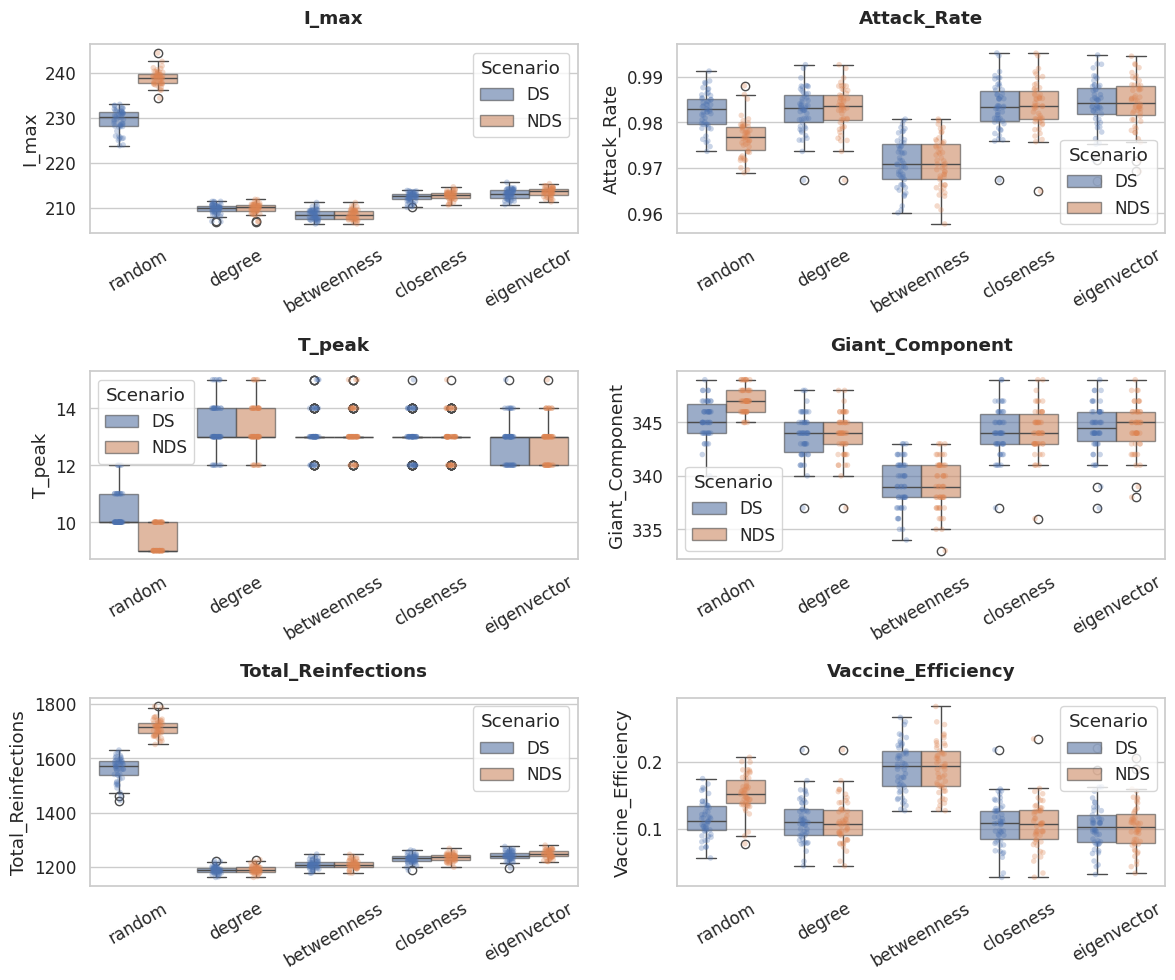

In [ ]:
# Call the function with your data
plot_metric_distributions(siri_full_df_ds, siri_full_df_nds,prefix='SIRI_BA', figsize=(12,10))

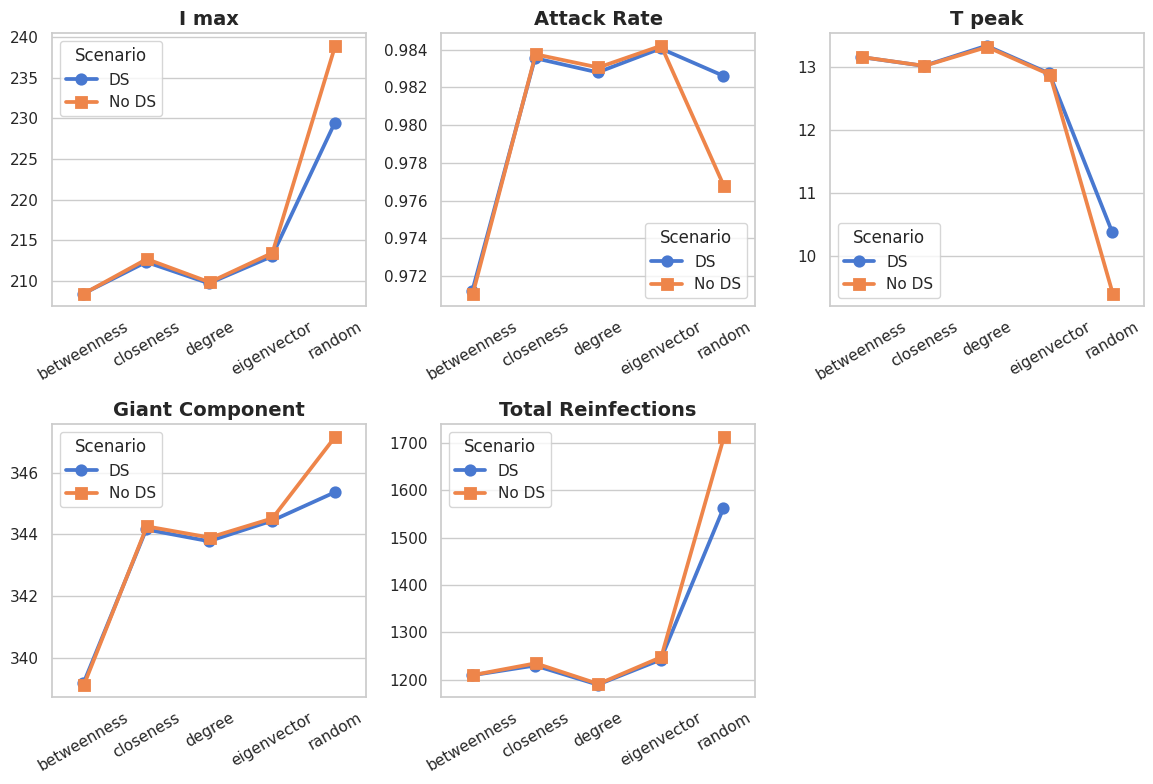


--- No Vaccination (DS) Baseline ---
Strategy      I_max  Attack_Rate  T_peak  Giant_Component  Total_Reinfections
  no_vac 286.038905     0.999764    8.06            410.0         2202.498179


In [ ]:
plot_comparison_bar_charts(siri_summary_df_ds, siri_summary_df_nds, prefix="SIRI_BA", dims=(2,3), figsize=(13,8))

## SIR MODEL

In [ ]:
sir_params = {
    'beta': 0.08,    # Standard transmission rate (S -> I)
    'gamma': 0.1,    # Standard recovery rate (I -> R)

    # --- CRUCIAL SIR ADJUSTMENT ---
    'epsilon': 0.0,  # ZERO reinfection for unvaccinated (No R -> I transition)
    'e': 0.0,        # ZERO reinfection for vaccinated (No R_v -> I_v transition)
    # -------------------------------

    # Vaccine efficacy parameters (S_v -> I_v)
    'b': 0.005,      # Very low transmission if the susceptible is vaccinated
    'g': 0.15,       # Infected vaccinated individuals recover even faster
    'h': 0.001       # An infected vaccinated individual contaminates almost no one (reduced contagiousness)
}

### Using Dominating Set

In [ ]:
params = sir_params # Use SIRI parameters
list_strategies = ["no_vac", "random", "degree", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

summary_df_ds, full_df_ds, summary_df_nds, full_df_nds = run_ensemble_analysis(
    pre_generated_networks=randomized_dublin_networks,
    params=params,
    vc=0.15, # Vaccination coverage (35%)
    m=100,
    strategies=list_strategies
)
sir_summary_df_ds = summary_df_ds
sir_full_df_ds = full_df_ds
sir_summary_df_nds = summary_df_nds
sir_full_df_nds = full_df_nds

#save to reuse later
sir_summary_df_ds.to_csv('sir_summary_df_ds.csv')
sir_full_df_ds.to_csv('sir_full_df_ds.csv')
sir_summary_df_nds.to_csv('sir_summary_df_nds.csv')
sir_full_df_nds.to_csv('sir_full_df_nds.csv')

Running ensemble analysis on 50 pre-generated networks...


In [ ]:
sir_summary_df_ds = pd.read_csv('sir_summary_df_ds.csv', header=[0, 1], index_col=0)
sir_full_df_ds = pd.read_csv('sir_full_df_ds.csv', index_col=0)
sir_summary_df_nds = pd.read_csv('sir_summary_df_nds.csv', header=[0, 1], index_col=0)
sir_full_df_nds = pd.read_csv('sir_full_df_nds.csv', index_col=0)

In [ ]:
# Display the analysis dashboard
print(sir_summary_df_ds[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component',  'Total_Reinfections']])


                             I_max           Attack_Rate           T_peak  \
                              mean       std        mean       std   mean   
betweenness_centrality  179.415467  1.041341    0.878733  0.005049  11.04   
closeness_centrality    183.112006  1.013180    0.890020  0.004239  11.08   
degree                  180.599395  0.993544    0.889780  0.004015  11.46   
eigenvector_centrality  183.774191  1.073367    0.889802  0.004246  10.90   
no_vac                  252.858073  0.778340    0.975275  0.000322   6.42   
random                  198.818787  2.179681    0.883669  0.003702   8.32   

                                 Giant_Component           Total_Reinfections  \
                             std            mean       std               mean   
betweenness_centrality  0.968061          339.18  2.282945           3.710112   
closeness_centrality    0.944155          344.16  2.188653           3.627060   
degree                  0.930438          343.78  2.073054 

In [ ]:
print(sir_summary_df_nds[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component',  'Total_Reinfections']])

                             I_max           Attack_Rate           T_peak  \
                              mean       std        mean       std   mean   
betweenness_centrality  179.442825  1.043539    0.878646  0.005030  11.04   
closeness_centrality    183.487521  0.961374    0.890275  0.004287  11.06   
degree                  180.755246  0.990162    0.889968  0.004061  11.46   
eigenvector_centrality  184.212635  0.962113    0.890127  0.004079  10.92   
no_vac                  252.858073  0.778340    0.975275  0.000322   6.42   
random                  209.563446  2.425089    0.881878  0.002482   7.44   

                                 Giant_Component           Total_Reinfections  \
                             std            mean       std               mean   
betweenness_centrality  0.968061          339.14  2.312433           3.707407   
closeness_centrality    0.934814          344.26  2.238896           3.606746   
degree                  0.930438          343.90  2.082483 

### Plots

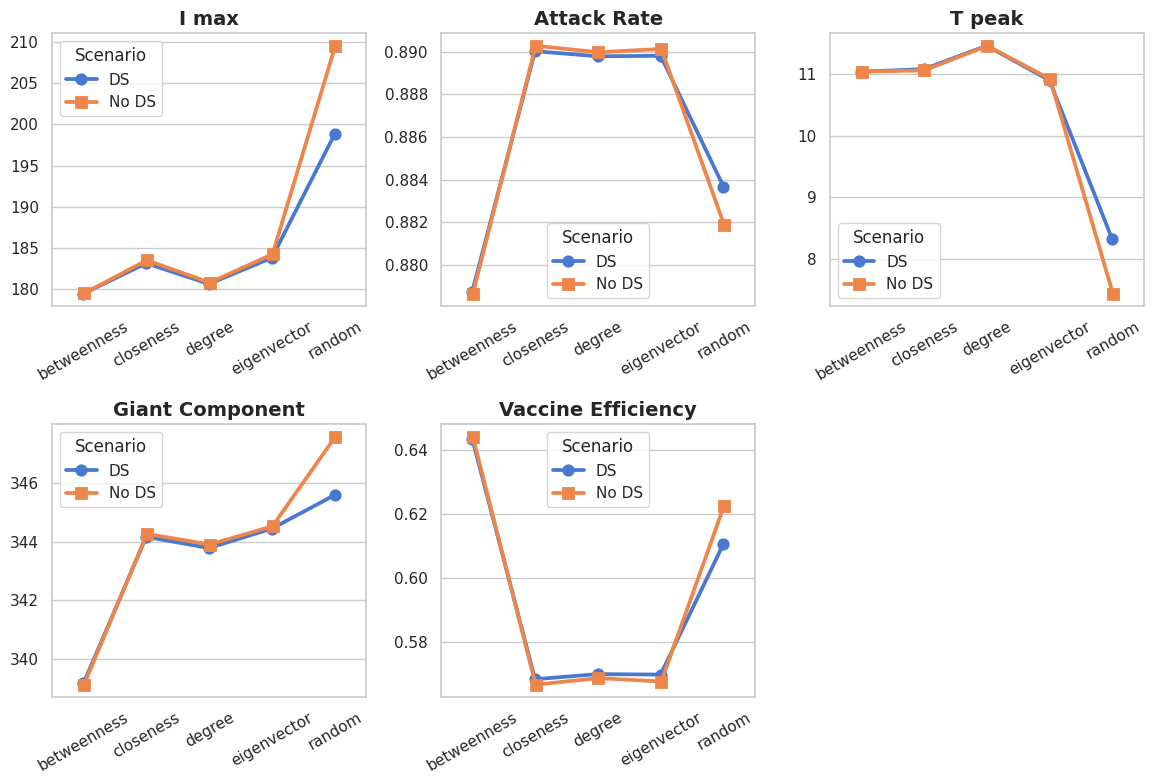


--- No Vaccination (DS) Baseline ---
Strategy      I_max  Attack_Rate  T_peak  Giant_Component  Vaccine_Efficiency
  no_vac 252.858073     0.975275    6.42            410.0                 0.0


In [ ]:
metrics = [
    'I_max',
    'Attack_Rate',
    'T_peak',
    'Giant_Component',
    'Vaccine_Efficiency'
]

plot_comparison_bar_charts(sir_summary_df_ds, sir_summary_df_nds, metrics=metrics, dims=(2,3),figsize=(13, 8), title_suffix="", prefix="SIR_BA")

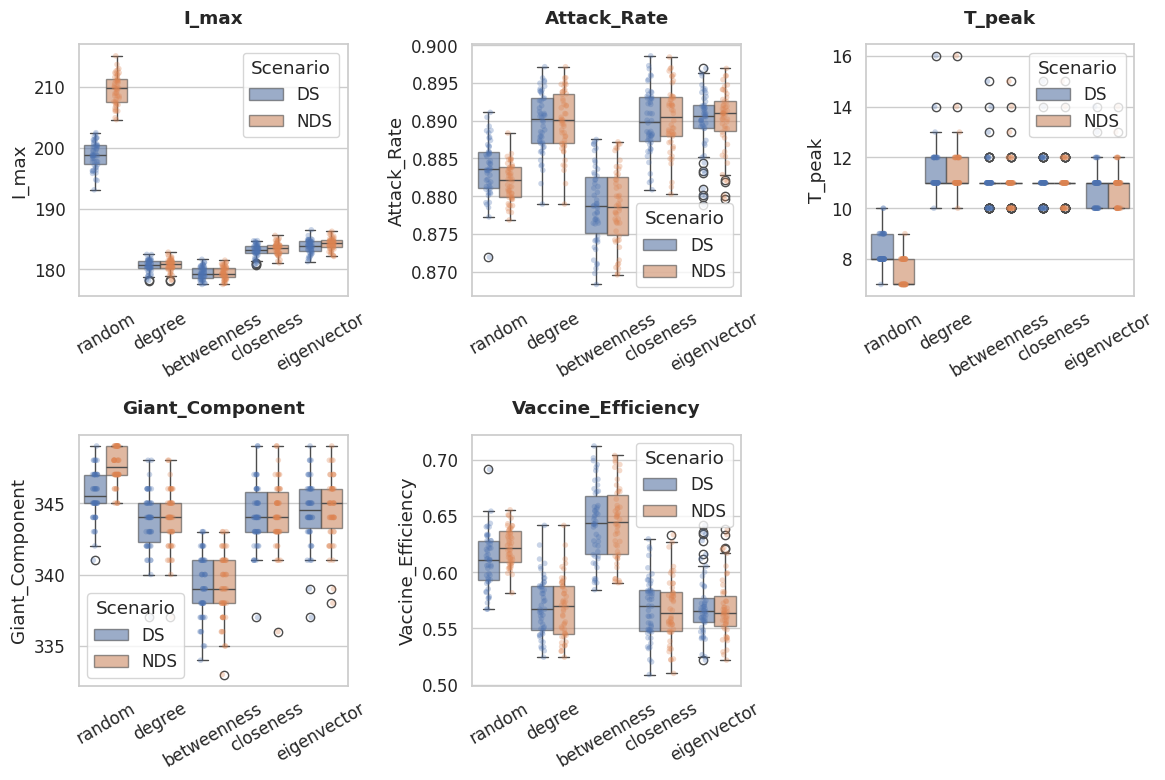

In [ ]:
plot_metric_distributions(sir_full_df_ds, sir_full_df_nds, metrics=metrics, prefix="SIR_BA", figsize=(12,8), dims=(2,2))

## SI MODEL

In [ ]:
si_params = {
    'beta': 0.08,    # Standard transmission rate (S -> I)

    # --- CRUCIAL SI ADJUSTMENT ---
    'gamma': 0.0,    # ZERO recovery for unvaccinated (No I -> R transition)
    'g': 0.0,        # ZERO recovery for vaccinated (No I_v -> R_v transition)

    'epsilon': 0.0,  # No reinfection (Useless because R remains empty)
    'e': 0.0,        # No reinfection for vaccinated individuals
    # -------------------------------

    # Vaccine efficacy parameters (S_v -> I_v)
    'b': 0.005,      # The vaccine reduces the probability that an S_v becomes I_v
    'h': 0.001       # An infected vaccinated individual (I_v) contaminates almost no one (reduced viral load/contagiousness)
}

In [ ]:
params = si_params # Use SIRI parameters
list_strategies = ["no_vac", "random", "degree", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

summary_df_ds,full_df_ds, summary_df_nds,full_df_nds= run_ensemble_analysis(
    pre_generated_networks=randomized_dublin_networks,
    params=params,
    vc=0.15,
    m=100,
    strategies=list_strategies
)
si_summary_df_ds = summary_df_ds
si_full_df_ds = full_df_ds
si_summary_df_nds = summary_df_nds
si_full_df_nds = full_df_nds

#save to reuse later
si_summary_df_ds.to_csv('si_summary_df_nds.csv')
si_full_df_ds.to_csv('si_full_df_nds.csv')
si_summary_df_nds.to_csv('si_summary_df_nds.csv')
si_full_df_nds.to_csv('si_full_df_nds.csv')

Running ensemble analysis on 50 pre-generated networks...


In [ ]:
si_summary_df_nds = pd.read_csv('si_summary_df_nds.csv', header=[0, 1], index_col=0)
si_full_df_nds = pd.read_csv('si_full_df_nds.csv', index_col=0)

In [ ]:
print(si_summary_df_ds[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component',  'Total_Reinfections']])

NameError: name 'si_summary_df_ds' is not defined

NameError: name 'si_summary_df_ds' is not defined

In [ ]:
print(si_summary_df_nds[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component',  'Total_Reinfections']])

                             I_max            Attack_Rate                \
                              mean        std        mean           std   
betweenness_centrality  349.317516  15.900969    0.698635  3.180194e-02   
closeness_centrality    421.949832  11.621118    0.843900  2.324224e-02   
degree                  325.999728  16.802294    0.651999  3.360459e-02   
eigenvector_centrality  428.106604  10.417287    0.856213  2.083457e-02   
no_vac                  499.999838   0.000075    1.000000  1.481777e-07   
random                  468.483423   3.511448    0.936967  7.022897e-03   

                       T_peak           Giant_Component             \
                         mean       std            mean        std   
betweenness_centrality  99.00  0.000000          112.72  54.006440   
closeness_centrality    99.00  0.000000          346.76  20.107426   
degree                  99.00  0.000000           71.08  37.435027   
eigenvector_centrality  99.00  0.000000          

### Plots

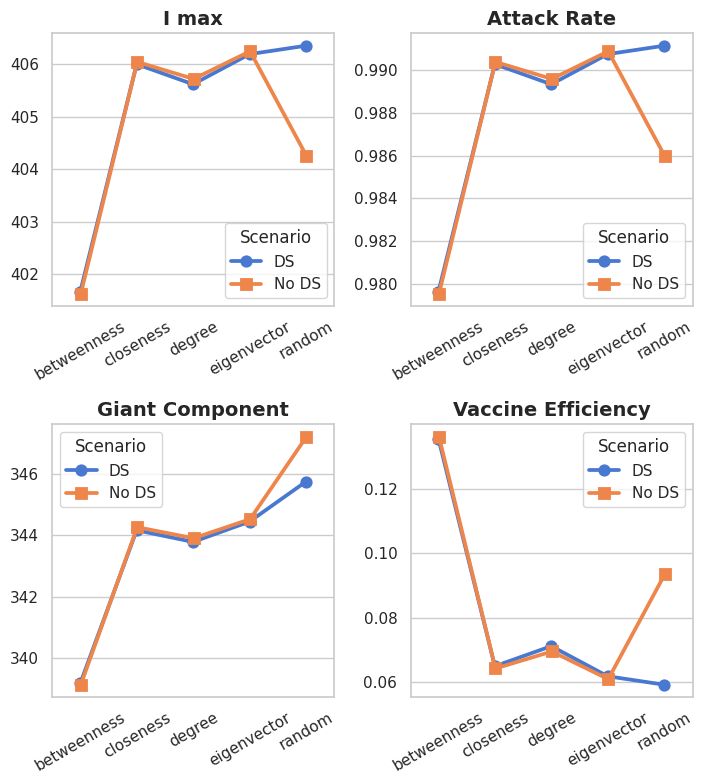


--- No Vaccination (DS) Baseline ---
Strategy      I_max  Attack_Rate  Giant_Component  Vaccine_Efficiency
  no_vac 409.995158     0.999988            410.0                 0.0


In [ ]:
metrics = [
    'I_max',
    'Attack_Rate',
    'Giant_Component',
    'Vaccine_Efficiency'
]

plot_comparison_bar_charts(si_summary_df_ds, si_summary_df_nds, metrics=metrics, figsize=(8, 8), title_suffix="", prefix="SI_BA", dims=(2,2))

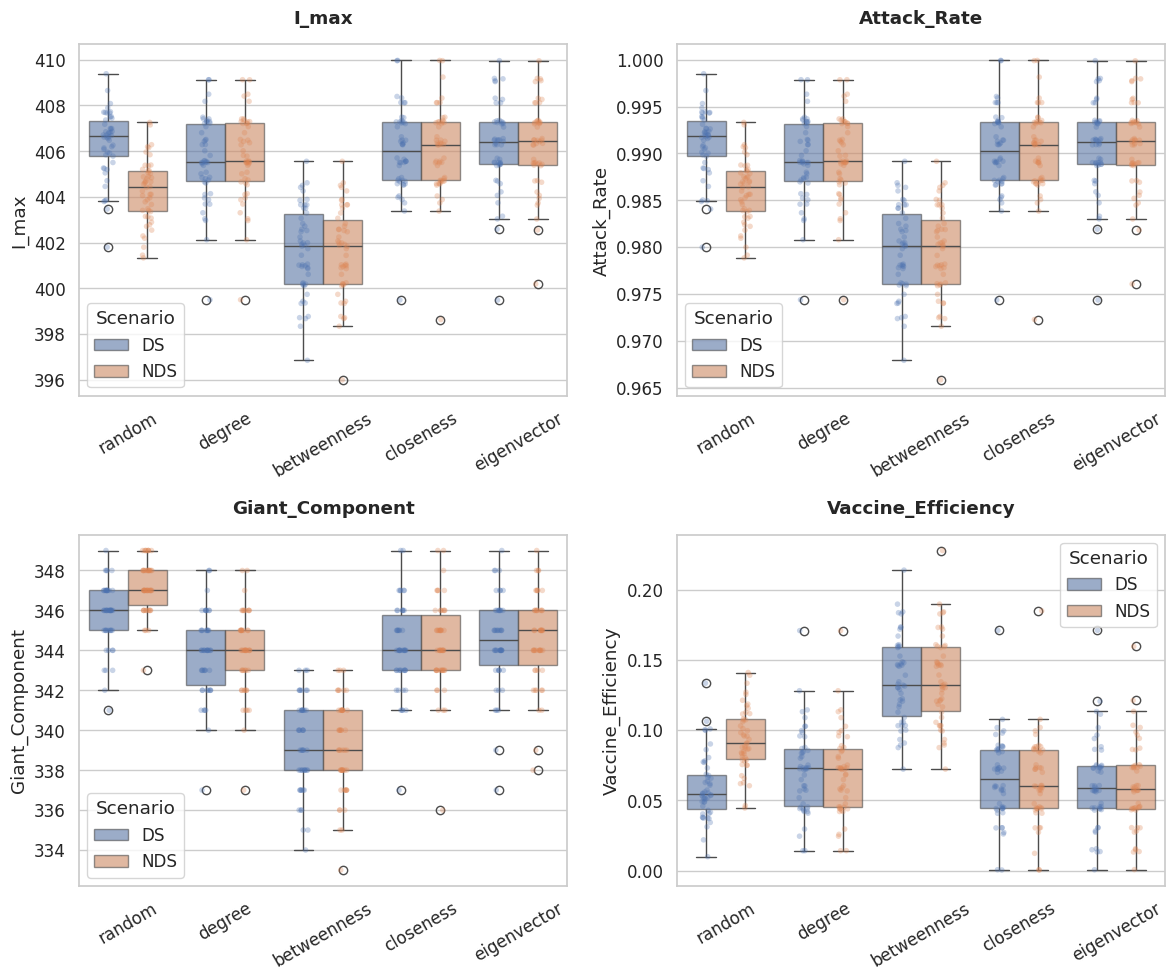

In [ ]:
plot_metric_distributions(si_full_df_ds, si_full_df_nds, metrics=metrics,figsize=(12,10), prefix="SI_BA",dims=(2,2))

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!mkdir -p /content/drive/MyDrive/Hassana_data
!cp -r *eps /content/drive/MyDrive/Hassana_data
!cp -r *csv /content/drive/MyDrive/Hassana_data

In [ ]:
import scipy.stats as stats
import pandas as pd

def perform_statistical_tests(model_name, ds_full_df, nds_full_df, metrics_to_test):
    print(f"--- Statistical Tests for {model_name} Model (DS vs. No DS) ---")
    strategies = [s for s in ds_full_df.index.unique() if s != 'no_vac']

    results = []

    for metric in metrics_to_test:
        print(f"\nMetric: {metric}")
        for strategy in strategies:
            ds_data = ds_full_df.loc[strategy, metric]
            nds_data = nds_full_df.loc[strategy, metric]

            # Perform independent samples t-test (Welch's t-test for unequal variances)
            # Filter out NaN/inf values if any, though ensemble results should ideally be clean
            ds_data = ds_data.dropna()
            nds_data = nds_data.dropna()

            if len(ds_data) < 2 or len(nds_data) < 2: # Need at least 2 samples for t-test
                t_stat = p_value = float('nan')
                conclusion = "Not enough data for test"
            elif ds_data.equals(nds_data): # If data is identical, p-value is 1 or very high
                 t_stat = 0.0
                 p_value = 1.0
                 conclusion = "Identical distributions (no difference)"
            else:
                t_stat, p_value = stats.ttest_ind(ds_data, nds_data, equal_var=False) # Welch's t-test, more robust
                if p_value < 0.05:
                    conclusion = "Significant difference (p < 0.05)"
                else:
                    conclusion = "No significant difference (p >= 0.05)"

            results.append({
                'Model': model_name,
                'Metric': metric,
                'Strategy': strategy,
                'T-Statistic': t_stat,
                'P-Value': p_value,
                'Conclusion': conclusion
            })
            print(f"  Strategy '{strategy}': T-Stat={t_stat:.3f}, P-Value={p_value:.3f} -> {conclusion}")

    return pd.DataFrame(results)

# Define the common metrics to test
common_metrics = [
    'I_max',
    'Attack_Rate',
    'T_peak',
    'Giant_Component',
    'Total_Reinfections',
    'Vaccine_Efficiency'
]

# Perform tests for SIRI model
print("\n\n")
siri_test_results = perform_statistical_tests("SIRI", siri_full_df_ds, siri_full_df_nds, common_metrics)
print("\nSIRI Model Summary of Statistical Tests:")
display(siri_test_results)

# Perform tests for SIR model
print("\n\n")
sir_test_results = perform_statistical_tests("SIR", sir_full_df_ds, sir_full_df_nds, common_metrics)
print("\nSIR Model Summary of Statistical Tests:")
display(sir_test_results)

# Perform tests for SI model
print("\n\n")
si_test_results = perform_statistical_tests("SI", si_full_df_ds, si_full_df_nds, common_metrics)
print("\nSI Model Summary of Statistical Tests:")
display(si_test_results)





--- Statistical Tests for SIRI Model (DS vs. No DS) ---

Metric: I_max
  Strategy 'random': T-Stat=-22.471, P-Value=0.000 -> Significant difference (p < 0.05)
  Strategy 'degree': T-Stat=-0.625, P-Value=0.533 -> No significant difference (p >= 0.05)
  Strategy 'betweenness_centrality': T-Stat=-0.094, P-Value=0.926 -> No significant difference (p >= 0.05)
  Strategy 'closeness_centrality': T-Stat=-1.955, P-Value=0.053 -> No significant difference (p >= 0.05)
  Strategy 'eigenvector_centrality': T-Stat=-2.202, P-Value=0.030 -> Significant difference (p < 0.05)

Metric: Attack_Rate
  Strategy 'random': T-Stat=7.353, P-Value=0.000 -> Significant difference (p < 0.05)
  Strategy 'degree': T-Stat=-0.273, P-Value=0.785 -> No significant difference (p >= 0.05)
  Strategy 'betweenness_centrality': T-Stat=0.115, P-Value=0.909 -> No significant difference (p >= 0.05)
  Strategy 'closeness_centrality': T-Stat=-0.194, P-Value=0.847 -> No significant difference (p >= 0.05)
  Strategy 'eigenvector

,Model,Metric,Strategy,T-Statistic,P-Value,Conclusion
0,SIRI,I_max,random,-22.470653,8.685276e-38,Significant difference (p < 0.05)
1,SIRI,I_max,degree,-0.624990,5.334303e-01,No significant difference (p >= 0.05)
2,SIRI,I_max,betweenness_centrality,-0.093744,9.255042e-01,No significant difference (p >= 0.05)
3,SIRI,I_max,closeness_centrality,-1.955358,5.340615e-02,No significant difference (p >= 0.05)
4,SIRI,I_max,eigenvector_centrality,-2.201590,3.008148e-02,Significant difference (p < 0.05)
5,SIRI,Attack_Rate,random,7.353420,5.912353e-11,Significant difference (p < 0.05)
6,SIRI,Attack_Rate,degree,-0.273000,7.854280e-01,No significant difference (p >= 0.05)
7,SIRI,Attack_Rate,betweenness_centrality,0.115098,9.086030e-01,No significant difference (p >= 0.05)
8,SIRI,Attack_Rate,closeness_centrality,-0.193804,8.467304e-01,No significant difference (p >= 0.05)
9,SIRI,Attack_Rate,eigenvector_centrality,-0.136095,8.920257e-01,No significant difference (p >= 0.05)





--- Statistical Tests for SIR Model (DS vs. No DS) ---

Metric: I_max
  Strategy 'random': T-Stat=-23.301, P-Value=0.000 -> Significant difference (p < 0.05)
  Strategy 'degree': T-Stat=-0.786, P-Value=0.434 -> No significant difference (p >= 0.05)
  Strategy 'betweenness_centrality': T-Stat=-0.131, P-Value=0.896 -> No significant difference (p >= 0.05)
  Strategy 'closeness_centrality': T-Stat=-1.901, P-Value=0.060 -> No significant difference (p >= 0.05)
  Strategy 'eigenvector_centrality': T-Stat=-2.151, P-Value=0.034 -> Significant difference (p < 0.05)

Metric: Attack_Rate
  Strategy 'random': T-Stat=2.842, P-Value=0.006 -> Significant difference (p < 0.05)
  Strategy 'degree': T-Stat=-0.233, P-Value=0.816 -> No significant difference (p >= 0.05)
  Strategy 'betweenness_centrality': T-Stat=0.087, P-Value=0.931 -> No significant difference (p >= 0.05)
  Strategy 'closeness_centrality': T-Stat=-0.300, P-Value=0.765 -> No significant difference (p >= 0.05)
  Strategy 'eigenvector_

,Model,Metric,Strategy,T-Statistic,P-Value,Conclusion
0,SIR,I_max,random,-23.300692,1.679385e-41,Significant difference (p < 0.05)
1,SIR,I_max,degree,-0.785657,4.339641e-01,No significant difference (p >= 0.05)
2,SIR,I_max,betweenness_centrality,-0.131219,8.958712e-01,No significant difference (p >= 0.05)
3,SIR,I_max,closeness_centrality,-1.901120,6.023238e-02,No significant difference (p >= 0.05)
4,SIR,I_max,eigenvector_centrality,-2.150801,3.398051e-02,Significant difference (p < 0.05)
5,SIR,Attack_Rate,random,2.841509,5.610449e-03,Significant difference (p < 0.05)
6,SIR,Attack_Rate,degree,-0.232877,8.163430e-01,No significant difference (p >= 0.05)
7,SIR,Attack_Rate,betweenness_centrality,0.087248,9.306524e-01,No significant difference (p >= 0.05)
8,SIR,Attack_Rate,closeness_centrality,-0.299838,7.649359e-01,No significant difference (p >= 0.05)
9,SIR,Attack_Rate,eigenvector_centrality,-0.389778,6.975478e-01,No significant difference (p >= 0.05)





--- Statistical Tests for SI Model (DS vs. No DS) ---

Metric: I_max
  Strategy 'random': T-Stat=7.537, P-Value=0.000 -> Significant difference (p < 0.05)
  Strategy 'degree': T-Stat=-0.277, P-Value=0.782 -> No significant difference (p >= 0.05)
  Strategy 'betweenness_centrality': T-Stat=0.094, P-Value=0.926 -> No significant difference (p >= 0.05)
  Strategy 'closeness_centrality': T-Stat=-0.116, P-Value=0.908 -> No significant difference (p >= 0.05)
  Strategy 'eigenvector_centrality': T-Stat=-0.144, P-Value=0.886 -> No significant difference (p >= 0.05)

Metric: Attack_Rate
  Strategy 'random': T-Stat=7.537, P-Value=0.000 -> Significant difference (p < 0.05)
  Strategy 'degree': T-Stat=-0.277, P-Value=0.782 -> No significant difference (p >= 0.05)
  Strategy 'betweenness_centrality': T-Stat=0.094, P-Value=0.926 -> No significant difference (p >= 0.05)
  Strategy 'closeness_centrality': T-Stat=-0.116, P-Value=0.908 -> No significant difference (p >= 0.05)
  Strategy 'eigenvector_

,Model,Metric,Strategy,T-Statistic,P-Value,Conclusion
0,SI,I_max,random,7.536567,2.455544e-11,Significant difference (p < 0.05)
1,SI,I_max,degree,-0.277169,7.822339e-01,No significant difference (p >= 0.05)
2,SI,I_max,betweenness_centrality,0.093514,9.256859e-01,No significant difference (p >= 0.05)
3,SI,I_max,closeness_centrality,-0.115848,9.080104e-01,No significant difference (p >= 0.05)
4,SI,I_max,eigenvector_centrality,-0.144164,8.856669e-01,No significant difference (p >= 0.05)
5,SI,Attack_Rate,random,7.536567,2.455544e-11,Significant difference (p < 0.05)
6,SI,Attack_Rate,degree,-0.277169,7.822339e-01,No significant difference (p >= 0.05)
7,SI,Attack_Rate,betweenness_centrality,0.093514,9.256859e-01,No significant difference (p >= 0.05)
8,SI,Attack_Rate,closeness_centrality,-0.115848,9.080104e-01,No significant difference (p >= 0.05)
9,SI,Attack_Rate,eigenvector_centrality,-0.144164,8.856669e-01,No significant difference (p >= 0.05)
